In [1]:
# Loading and Exploring The Data
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_data/Airlines.csv')

In [2]:
# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (539383, 9)

Column names: ['id', 'Airline', 'Flight', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length', 'Delay']

First 5 rows:


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


In [3]:
# Missing Values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64


In [4]:
# Data Types
print("\nBasic statistics:")
df.describe()


Basic statistics:


,id,Flight,DayOfWeek,Time,Length,Delay
count,539383.00000,539383.000000,539383.000000,539383.000000,539383.000000,539383.000000
mean,269692.00000,2427.928630,3.929668,802.728963,132.202007,0.445442
std,155706.60446,2067.429837,1.914664,278.045911,70.117016,0.497015
min,1.00000,1.000000,1.000000,10.000000,0.000000,0.000000
25%,134846.50000,712.000000,2.000000,565.000000,81.000000,0.000000
50%,269692.00000,1809.000000,4.000000,795.000000,115.000000,0.000000
75%,404537.50000,3745.000000,5.000000,1035.000000,162.000000,1.000000
max,539383.00000,7814.000000,7.000000,1439.000000,655.000000,1.000000


In [5]:
# Visualization

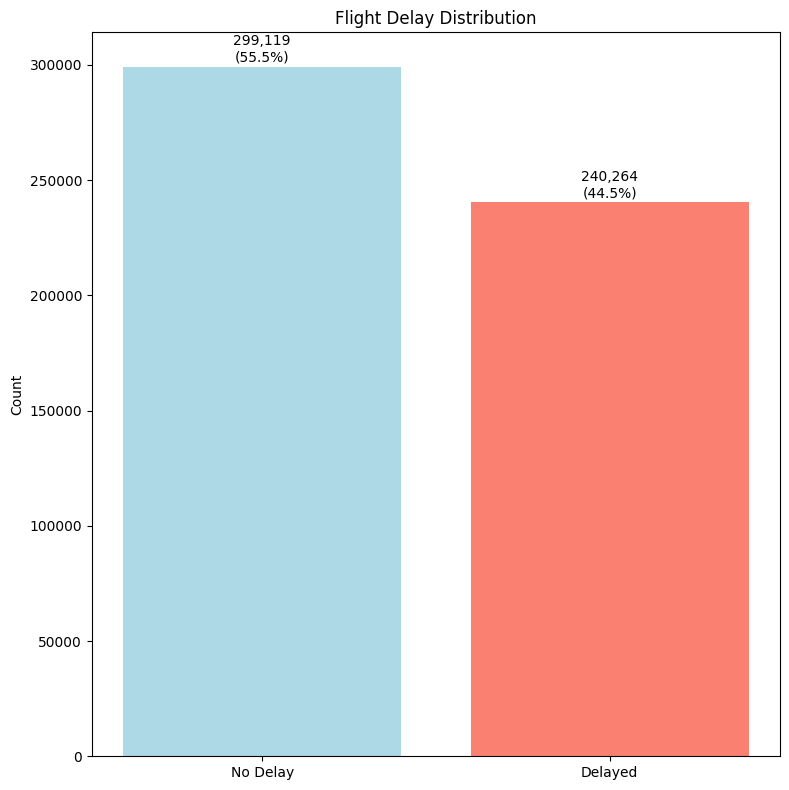

Overall delay rate: 44.54%
No delay rate: 55.46%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Chart
plt.figure(figsize=(8, 8))

delay_counts = df['Delay'].value_counts()
delay_percentages = df['Delay'].value_counts(normalize=True) * 100

plt.bar(['No Delay', 'Delayed'], delay_counts.values, color=['lightblue', 'salmon'])
plt.title('Flight Delay Distribution')
plt.ylabel('Count')

for i, (count, percentage) in enumerate(zip(delay_counts.values, delay_percentages.values)):
    plt.text(i, count + 1000, f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Overall delay rate: {df['Delay'].mean():.2%}")
print(f"No delay rate: {(1-df['Delay'].mean()):.2%}")

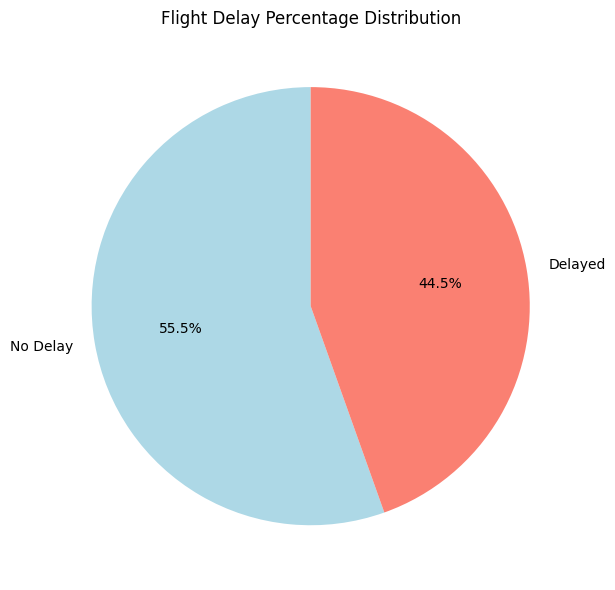

In [7]:
# Pie Chart
plt.figure(figsize=(8, 6))

delay_counts = df['Delay'].value_counts()
plt.pie(delay_counts.values, labels=['No Delay', 'Delayed'], autopct='%1.1f%%',
        colors=['lightblue', 'salmon'], startangle=90)
plt.title('Flight Delay Percentage Distribution')

plt.tight_layout()
plt.show()

In [8]:
# Data Preprocessing and Cleaning

In [9]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df_clean = df.dropna()

df_clean = df_clean.drop_duplicates()

print(f"\nDataset shape after cleaning: {df_clean.shape}")
print(f"Removed {len(df) - len(df_clean)} rows")

print(f"\nUnique Airlines: {df_clean['Airline'].nunique()}")
print(f"Airlines: {df_clean['Airline'].unique()}")
print(f"\nDay of Week range: {df_clean['DayOfWeek'].min()} to {df_clean['DayOfWeek'].max()}")
print(f"Time range: {df_clean['Time'].min()} to {df_clean['Time'].max()}")

Missing values before cleaning:
id             0
Airline        0
Flight         0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Time           0
Length         0
Delay          0
dtype: int64

Dataset shape after cleaning: (539383, 9)
Removed 0 rows

Unique Airlines: 18
Airlines: ['CO' 'US' 'AA' 'AS' 'DL' 'B6' 'HA' 'OO' '9E' 'OH' 'EV' 'XE' 'YV' 'UA'
 'MQ' 'FL' 'F9' 'WN']

Day of Week range: 1 to 7
Time range: 10 to 1439


In [10]:
# Extract Time-Based Features

In [11]:
df_clean['Hour'] = (df_clean['Time'] // 60).astype(int)
df_clean['Minute'] = (df_clean['Time'] % 60).astype(int)

def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_clean['TimePeriod'] = df_clean['Hour'].apply(get_time_period)

df_clean['DayType'] = df_clean['DayOfWeek'].apply(lambda x: 'Weekend' if x in [6, 7] else 'Weekday')

print("Time-based features created:")
print(f"Hour range: {df_clean['Hour'].min()} to {df_clean['Hour'].max()}")
print(f"Time periods: {df_clean['TimePeriod'].unique()}")
print(f"Day types: {df_clean['DayType'].unique()}")

Time-based features created:
Hour range: 0 to 23
Time periods: ['Night' 'Morning' 'Afternoon' 'Evening']
Day types: ['Weekday' 'Weekend']


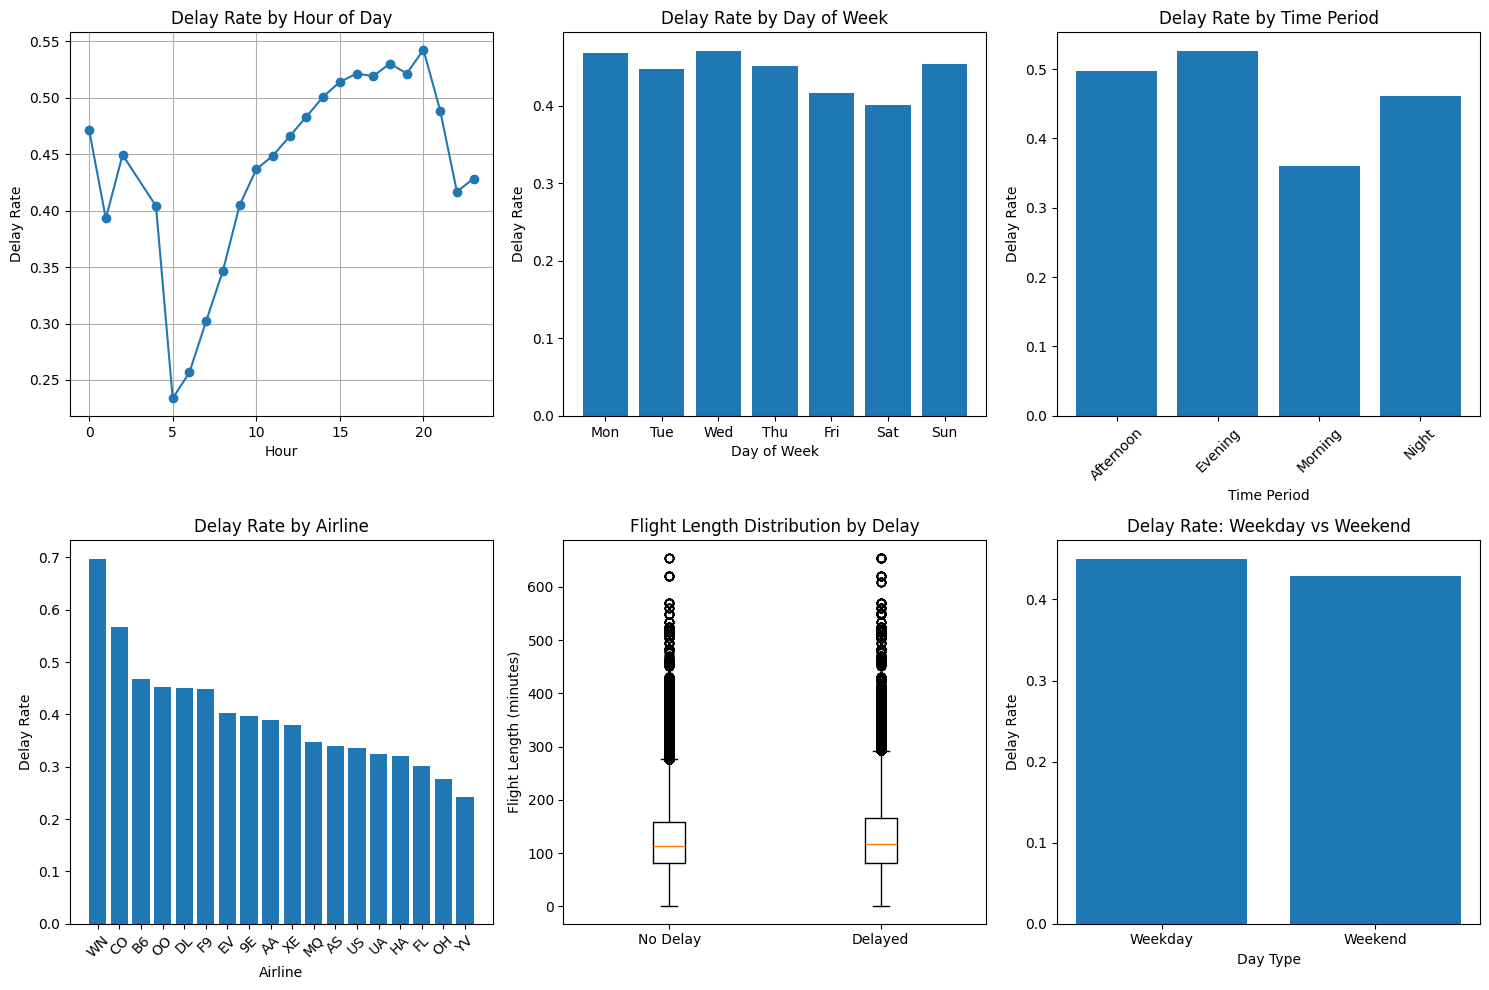

In [13]:
plt.figure(figsize=(15, 10))

# Delay rate by hour of day
plt.subplot(2, 3, 1)
hourly_delay = df_clean.groupby('Hour')['Delay'].mean()
plt.plot(hourly_delay.index, hourly_delay.values, marker='o')
plt.title('Delay Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Delay Rate')
plt.grid(True)

# Delay rate by day of week
plt.subplot(2, 3, 2)
daily_delay = df_clean.groupby('DayOfWeek')['Delay'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(range(1, 8), daily_delay.values)
plt.title('Delay Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Delay Rate')
plt.xticks(range(1, 8), days)

# Delay rate by time period
plt.subplot(2, 3, 3)
period_delay = df_clean.groupby('TimePeriod')['Delay'].mean()
plt.bar(period_delay.index, period_delay.values)
plt.title('Delay Rate by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)

# Delay rate by airline
plt.subplot(2, 3, 4)
airline_delay = df_clean.groupby('Airline')['Delay'].mean().sort_values(ascending=False)
plt.bar(range(len(airline_delay)), airline_delay.values)
plt.title('Delay Rate by Airline')
plt.xlabel('Airline')
plt.ylabel('Delay Rate')
plt.xticks(range(len(airline_delay)), airline_delay.index, rotation=45)

# Flight length vs delay
plt.subplot(2, 3, 5)
plt.boxplot([df_clean[df_clean['Delay']==0]['Length'],
             df_clean[df_clean['Delay']==1]['Length']],
            tick_labels=['No Delay', 'Delayed'])
plt.title('Flight Length Distribution by Delay')
plt.ylabel('Flight Length (minutes)')

# Weekday vs Weekend
plt.subplot(2, 3, 6)
daytype_delay = df_clean.groupby('DayType')['Delay'].mean()
plt.bar(daytype_delay.index, daytype_delay.values)
plt.title('Delay Rate: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Delay Rate')

plt.tight_layout()
plt.show()

In [ ]:
# Apply Cyclical Encoding to Time Features

In [15]:
def cyclical_encode(data, col, max_val):

    data[col + '_sin'] = np.sin(2 * np.pi * data[col] / max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col] / max_val)
    return data

df_clean = cyclical_encode(df_clean, 'Hour', 24)
df_clean = cyclical_encode(df_clean, 'DayOfWeek', 7)
df_clean = cyclical_encode(df_clean, 'Minute', 60)

print("New columns created:")
cyclical_cols = [col for col in df_clean.columns if '_sin' in col or '_cos' in col]
print(cyclical_cols)

print("\nSample of cyclical features:")
df_clean[['Hour', 'Hour_sin', 'Hour_cos', 'DayOfWeek', 'DayOfWeek_sin', 'DayOfWeek_cos']].head(10)

New columns created:
['Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Minute_sin', 'Minute_cos']

Sample of cyclical features:


,Hour,Hour_sin,Hour_cos,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
0,0,0.0,1.0,3,0.433884,-0.900969
1,0,0.0,1.0,3,0.433884,-0.900969
2,0,0.0,1.0,3,0.433884,-0.900969
3,0,0.0,1.0,3,0.433884,-0.900969
4,0,0.0,1.0,3,0.433884,-0.900969
5,0,0.0,1.0,3,0.433884,-0.900969
6,0,0.0,1.0,3,0.433884,-0.900969
7,0,0.0,1.0,3,0.433884,-0.900969
8,0,0.0,1.0,3,0.433884,-0.900969
9,0,0.0,1.0,3,0.433884,-0.900969


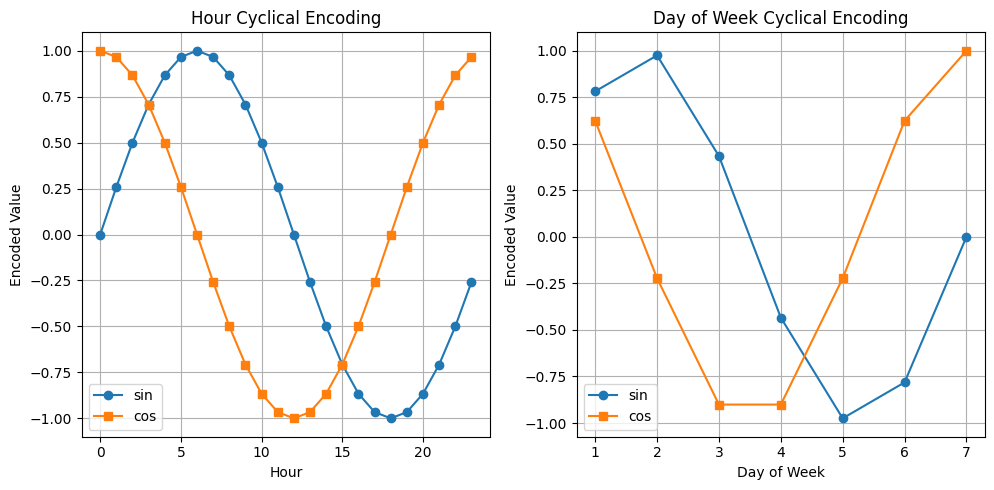

In [17]:
# Visualize cyclical encoding
plt.figure(figsize=(15, 5))

# Hour cyclical encoding
plt.subplot(1, 3, 1)
hours = range(24)
hour_sin = np.sin(2 * np.pi * np.array(hours) / 24)
hour_cos = np.cos(2 * np.pi * np.array(hours) / 24)
plt.plot(hours, hour_sin, label='sin', marker='o')
plt.plot(hours, hour_cos, label='cos', marker='s')
plt.title('Hour Cyclical Encoding')
plt.xlabel('Hour')
plt.ylabel('Encoded Value')
plt.legend()
plt.grid(True)

# Day of week cyclical encoding
plt.subplot(1, 3, 2)
days = range(1, 8)
day_sin = np.sin(2 * np.pi * np.array(days) / 7)
day_cos = np.cos(2 * np.pi * np.array(days) / 7)
plt.plot(days, day_sin, label='sin', marker='o')
plt.plot(days, day_cos, label='cos', marker='s')
plt.title('Day of Week Cyclical Encoding')
plt.xlabel('Day of Week')
plt.ylabel('Encoded Value')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


In [ ]:
# Feature Engineering for Airlines and Routes

In [18]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode categorical variables
label_encoders = {}

# Encode Airline
le_airline = LabelEncoder()
df_clean['Airline_encoded'] = le_airline.fit_transform(df_clean['Airline'])
label_encoders['Airline'] = le_airline

# Encode Airports
le_from = LabelEncoder()
df_clean['AirportFrom_encoded'] = le_from.fit_transform(df_clean['AirportFrom'])
label_encoders['AirportFrom'] = le_from

le_to = LabelEncoder()
df_clean['AirportTo_encoded'] = le_to.fit_transform(df_clean['AirportTo'])
label_encoders['AirportTo'] = le_to

# Encode Time Period
le_period = LabelEncoder()
df_clean['TimePeriod_encoded'] = le_period.fit_transform(df_clean['TimePeriod'])
label_encoders['TimePeriod'] = le_period

# Route features
df_clean['Route'] = df_clean['AirportFrom'] + '_' + df_clean['AirportTo']
route_delay_rate = df_clean.groupby('Route')['Delay'].mean()
df_clean['Route_delay_rate'] = df_clean['Route'].map(route_delay_rate)

# Airline performance features
airline_delay_rate = df_clean.groupby('Airline')['Delay'].mean()
df_clean['Airline_delay_rate'] = df_clean['Airline'].map(airline_delay_rate)

# Airport congestion features
airport_hour_counts = df_clean.groupby(['AirportFrom', 'Hour']).size().reset_index(name='From_airport_hourly_flights')
df_clean = df_clean.merge(airport_hour_counts, on=['AirportFrom', 'Hour'], how='left')


print(f"Total features: {len(df_clean.columns)}")
print(f"\nNew engineered features:")
new_features = ['Airline_encoded', 'AirportFrom_encoded', 'AirportTo_encoded',
                'TimePeriod_encoded', 'Route_delay_rate', 'Airline_delay_rate',
                'From_airport_hourly_flights']
print(new_features)

Total features: 27

New engineered features:
['Airline_encoded', 'AirportFrom_encoded', 'AirportTo_encoded', 'TimePeriod_encoded', 'Route_delay_rate', 'Airline_delay_rate', 'From_airport_hourly_flights']


In [ ]:
# Prepare Data for Machine Learning

In [19]:
feature_columns = [
    'Length', 'Flight',
    'Hour_sin', 'Hour_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
    'Minute_sin', 'Minute_cos',
    'Airline_encoded', 'AirportFrom_encoded', 'AirportTo_encoded',
    'TimePeriod_encoded',
    'Route_delay_rate', 'Airline_delay_rate', 'From_airport_hourly_flights'
]

X = df_clean[feature_columns]
y = df_clean['Delay']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures used:")
for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2d}. {feature}")

print(f"\nMissing values in features:")
print(X.isnull().sum().sum())

Feature matrix shape: (539383, 15)
Target vector shape: (539383,)

Features used:
 1. Length
 2. Flight
 3. Hour_sin
 4. Hour_cos
 5. DayOfWeek_sin
 6. DayOfWeek_cos
 7. Minute_sin
 8. Minute_cos
 9. Airline_encoded
10. AirportFrom_encoded
11. AirportTo_encoded
12. TimePeriod_encoded
13. Route_delay_rate
14. Airline_delay_rate
15. From_airport_hourly_flights

Missing values in features:
0


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set delay rate: {y_train.mean():.2%}")
print(f"Testing set delay rate: {y_test.mean():.2%}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled using StandardScaler")
print(f"Feature means after scaling (should be ~0): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Feature stds after scaling (should be ~1): {X_train_scaled.std(axis=0)[:5]}")

Training set size: 431506
Testing set size: 107877

Training set delay rate: 44.54%
Testing set delay rate: 44.54%

Features scaled using StandardScaler
Feature means after scaling (should be ~0): [ 1.74907995e-16  2.94422421e-17 -2.31026094e-17 -5.57558343e-17
  2.25262792e-17]
Feature stds after scaling (should be ~1): [1. 1. 1. 1. 1.]


In [ ]:
# Train Prediction Models

In [21]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

model_results = {}
trained_models = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")

    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    model_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = model

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}\n")

Training models...

Training Random Forest...
  Accuracy: 0.6184
  Precision: 0.5742
  Recall: 0.5544
  F1-Score: 0.5641

Training Gradient Boosting...
  Accuracy: 0.6632
  Precision: 0.6630
  Recall: 0.4961
  F1-Score: 0.5675

Training Logistic Regression...
  Accuracy: 0.6572
  Precision: 0.6497
  Recall: 0.5002
  F1-Score: 0.5652



In [ ]:
# Evaluate Model Performance

In [23]:
results_df = pd.DataFrame(model_results).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1']]

print("Model Performance Comparison:")
print(results_df.round(4))

Model Performance Comparison:
                     accuracy precision    recall        f1
Random Forest        0.618389  0.574206  0.554429  0.564144
Gradient Boosting      0.6632  0.662986  0.496056    0.5675
Logistic Regression  0.657221  0.649666  0.500219  0.565231


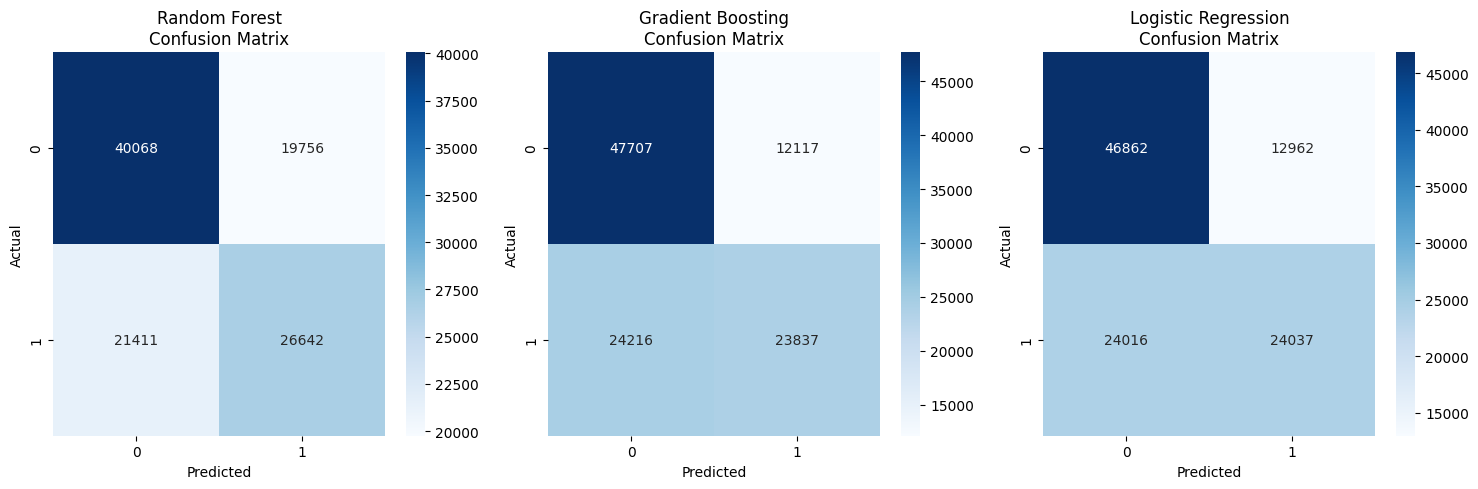

In [24]:
plt.figure(figsize=(15, 5))

# Confusion matrices
for i, (name, results) in enumerate(model_results.items()):
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name}\nConfusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()